In [50]:
import pandas as pd
turab = pd.read_csv('/content/drive/MyDrive/weather_sydney.csv',index_col =0,parse_dates=True)
turab

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
Date,,,,,,,,,,,,,,,,
2013-03-01,16.5,20.1,31.8,6.8,0.0,63.0,26.0,26.0,86.0,85.0,1014.4,1016.2,8.0,8.0,19.5,18.7
2013-03-02,17.9,23.1,15.2,6.2,0.1,57.0,30.0,31.0,73.0,78.0,1021.0,1020.8,7.0,8.0,19.0,20.1
2013-03-03,17.7,25.5,7.4,4.8,6.8,56.0,30.0,30.0,63.0,56.0,1021.6,1020.4,7.0,6.0,23.1,24.8
2013-03-04,19.5,26.1,4.4,6.6,9.6,39.0,22.0,22.0,53.0,49.0,1021.9,1020.9,3.0,3.0,23.7,25.1
2013-03-05,20.5,26.8,0.2,6.0,9.1,35.0,20.0,28.0,70.0,48.0,1021.7,1020.0,6.0,3.0,23.1,25.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-06-21,8.6,19.6,0.0,2.0,7.8,37.0,22.0,20.0,73.0,52.0,1025.9,1025.3,2.0,2.0,10.5,17.9
2017-06-22,9.3,19.2,0.0,2.0,9.2,30.0,20.0,7.0,78.0,53.0,1028.5,1024.6,2.0,2.0,11.0,18.7
2017-06-23,9.4,17.7,0.0,2.4,2.7,24.0,15.0,13.0,85.0,56.0,1020.8,1015.0,6.0,6.0,10.2,17.3


<Axes: ylabel='Date'>

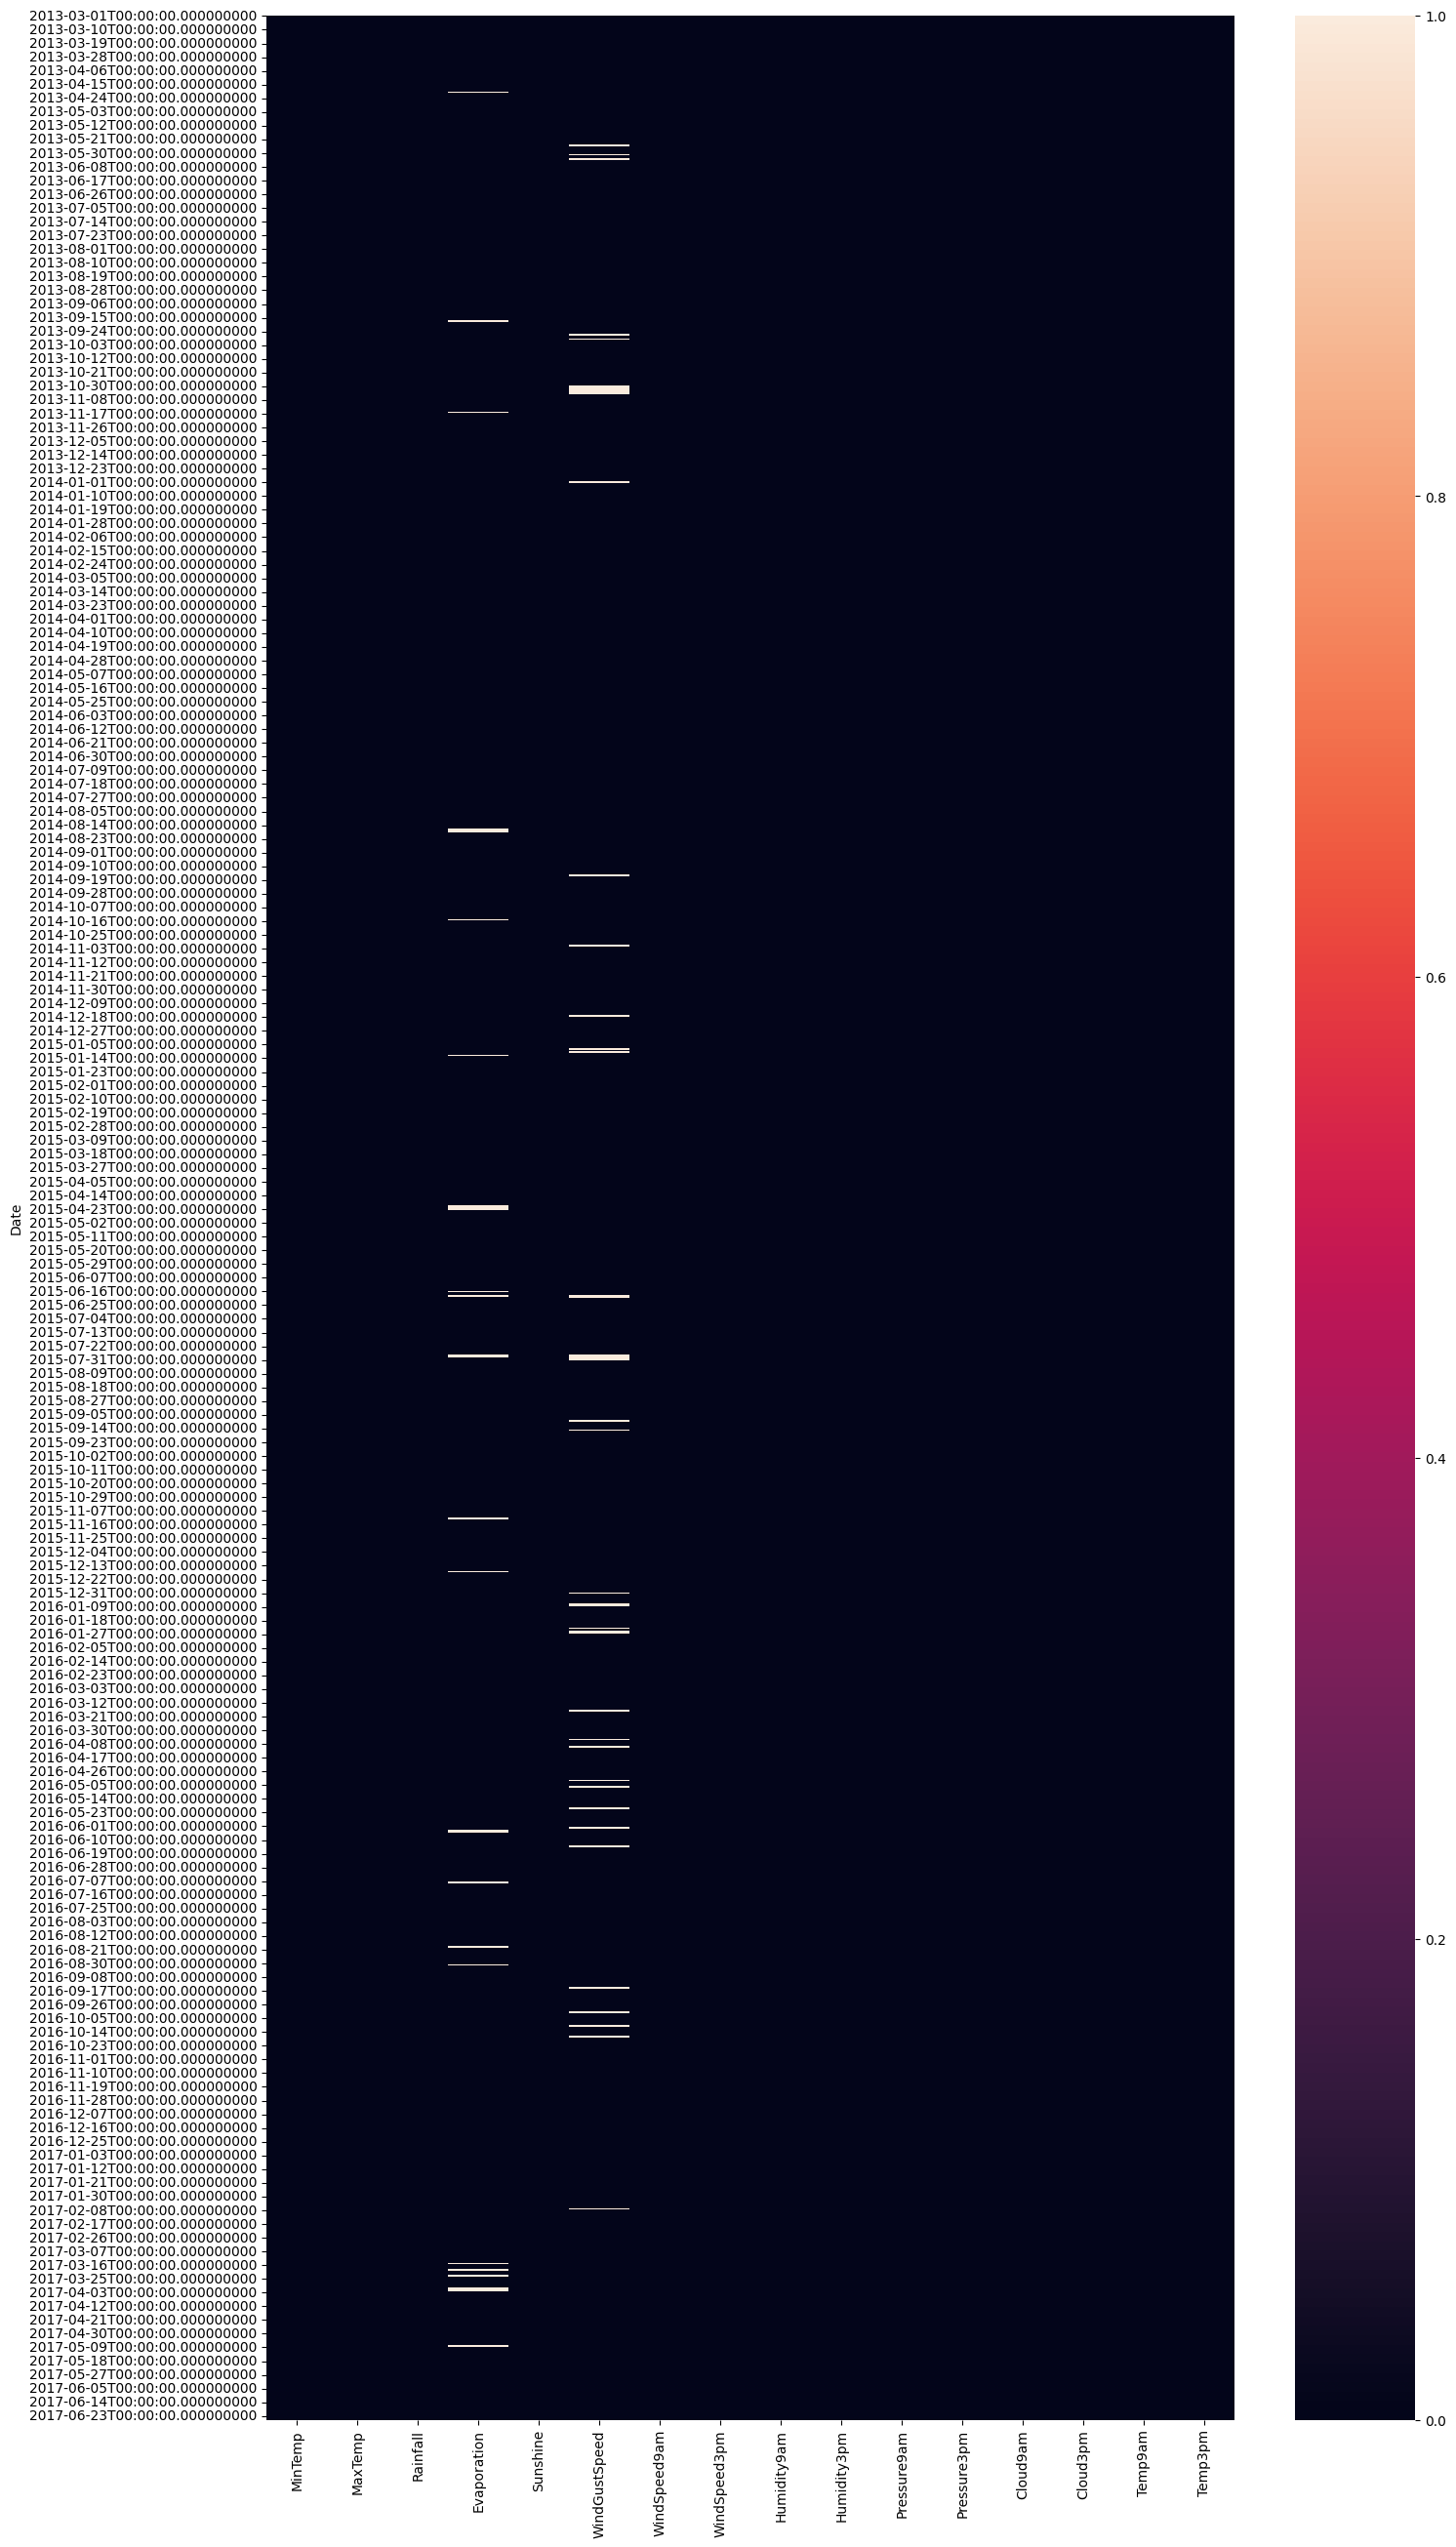

In [51]:
#check for holes in the turab

import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(16,32))
sns.heatmap(turab.isna())

In [52]:
#filling the gaps with interplotaion
turab['Evaporation'] = turab['Evaporation'].interpolate()
turab['WindGustSpeed'] = turab['WindGustSpeed'].interpolate(method='quadratic')



In [53]:
#create Rainy Day Column
turab['Rainy_Day'] = turab['Rainfall']>=1.0

In [54]:
turab

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Rainy_Day
Date,,,,,,,,,,,,,,,,,
2013-03-01,16.5,20.1,31.8,6.8,0.0,63.0,26.0,26.0,86.0,85.0,1014.4,1016.2,8.0,8.0,19.5,18.7,True
2013-03-02,17.9,23.1,15.2,6.2,0.1,57.0,30.0,31.0,73.0,78.0,1021.0,1020.8,7.0,8.0,19.0,20.1,True
2013-03-03,17.7,25.5,7.4,4.8,6.8,56.0,30.0,30.0,63.0,56.0,1021.6,1020.4,7.0,6.0,23.1,24.8,True
2013-03-04,19.5,26.1,4.4,6.6,9.6,39.0,22.0,22.0,53.0,49.0,1021.9,1020.9,3.0,3.0,23.7,25.1,True
2013-03-05,20.5,26.8,0.2,6.0,9.1,35.0,20.0,28.0,70.0,48.0,1021.7,1020.0,6.0,3.0,23.1,25.8,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-06-21,8.6,19.6,0.0,2.0,7.8,37.0,22.0,20.0,73.0,52.0,1025.9,1025.3,2.0,2.0,10.5,17.9,False
2017-06-22,9.3,19.2,0.0,2.0,9.2,30.0,20.0,7.0,78.0,53.0,1028.5,1024.6,2.0,2.0,11.0,18.7,False
2017-06-23,9.4,17.7,0.0,2.4,2.7,24.0,15.0,13.0,85.0,56.0,1020.8,1015.0,6.0,6.0,10.2,17.3,False


In [55]:
#Predict Rainy Day without Forecast

#Train-test split
turab_train = turab[ : "2017-01-01"]
turab_test = turab[ "2017-01-01" : ]

In [56]:
# seperate training x and y
train_y = turab_train['Rainy_Day']
train_x = turab_train.drop(columns=['Rainy_Day', 'Rainfall'],axis=1)


In [57]:
# seperate targets x and y
test_y = turab_test['Rainy_Day']
test_x = turab_test.drop(columns=['Rainy_Day', 'Rainfall'],axis=1)

In [58]:
#using tensorflow library for dense layers
import tensorflow as tf

model = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(input_shape=(train_x.shape[1])),
    tf.keras.layers.Dense(128,activation="relu"),
    tf.keras.layers.Dense(64,activation="relu"),
    tf.keras.layers.Dense(1,activation="sigmoid")
    ])
model.compile(
    loss="binary_focal_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
    )


In [59]:
#fitting the model to train and test Turab
model.fit(train_x,train_y,epochs=40,validation_data=(test_x,test_y))

Epoch 1/40
44/44 [==============================] - 1s 8ms/step - loss: 1.7857 - accuracy: 0.7106 - val_loss: 1.4098 - val_accuracy: 0.5057
Epoch 2/40
44/44 [==============================] - 0s 4ms/step - loss: 0.7431 - accuracy: 0.7163 - val_loss: 0.4978 - val_accuracy: 0.6307
Epoch 3/40
44/44 [==============================] - 0s 4ms/step - loss: 1.3023 - accuracy: 0.6871 - val_loss: 0.6600 - val_accuracy: 0.7557
Epoch 4/40
44/44 [==============================] - 0s 3ms/step - loss: 0.6645 - accuracy: 0.7284 - val_loss: 0.4094 - val_accuracy: 0.7670
Epoch 5/40
44/44 [==============================] - 0s 4ms/step - loss: 0.3583 - accuracy: 0.7541 - val_loss: 0.6401 - val_accuracy: 0.7273
Epoch 6/40
44/44 [==============================] - 0s 3ms/step - loss: 0.8797 - accuracy: 0.6771 - val_loss: 0.2056 - val_accuracy: 0.7727
Epoch 7/40
44/44 [==============================] - 0s 4ms/step - loss: 0.9385 - accuracy: 0.6928 - val_loss: 4.5515 - val_accuracy: 0.6648
Epoch 8/40
44/44 [==

In [23]:
model.evaluate(test_x,test_y)

6/6 [==============================] - 0s 3ms/step - loss: 0.0099 - accuracy: 0.9830


[0.00991732720285654, 0.9829545617103577]

In [62]:
#Predict Rainy Day by Forecast

import tensorflow as tf

# convert to time series data
turab_train = tf.keras.utils.timeseries_dataset_from_array(
    train_x[: -7],
    train_y[7 :],
    sequence_length=7,
    sequence_stride=1,
    batch_size=32,
    shuffle=True
)

In [63]:
#Predict Rainy Day by Forecast

import tensorflow as tf

# convert to time series data
turab_test = tf.keras.utils.timeseries_dataset_from_array(
    test_x[: -7],
    test_y[7 :],
    sequence_length=7,
    sequence_stride=1,
    batch_size=32,
    shuffle=True
)

In [76]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(7,15)),
    tf.keras.layers.LSTM(128,return_sequences=True),
    tf.keras.layers.LSTM(128),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
model.compile(
    loss="binary_focal_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [72]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 7, 128)            73728     
                                                                 
 lstm_1 (LSTM)               (None, 128)               131584    
                                                                 
 dense_6 (Dense)             (None, 1)                 129       
                                                                 
Total params: 205441 (802.50 KB)
Trainable params: 205441 (802.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


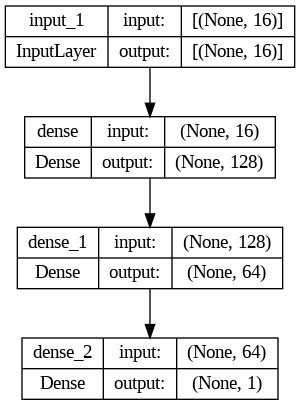

In [37]:
#display model
tf.keras.utils.plot_model(model,show_shapes=True)

In [77]:
model.fit(turab_train,epochs=40,validation_data=turab_test)

Epoch 1/40
44/44 [==============================] - 8s 65ms/step - loss: 0.1474 - accuracy: 0.7353 - val_loss: 0.1516 - val_accuracy: 0.6748
Epoch 2/40
44/44 [==============================] - 1s 28ms/step - loss: 0.1316 - accuracy: 0.7525 - val_loss: 0.1362 - val_accuracy: 0.7423
Epoch 3/40
44/44 [==============================] - 1s 31ms/step - loss: 0.1234 - accuracy: 0.7892 - val_loss: 0.1294 - val_accuracy: 0.7301
Epoch 4/40
44/44 [==============================] - 1s 31ms/step - loss: 0.1172 - accuracy: 0.8050 - val_loss: 0.1188 - val_accuracy: 0.7853
Epoch 5/40
44/44 [==============================] - 1s 32ms/step - loss: 0.1175 - accuracy: 0.7871 - val_loss: 0.1087 - val_accuracy: 0.8160
Epoch 6/40
44/44 [==============================] - 1s 32ms/step - loss: 0.1136 - accuracy: 0.8079 - val_loss: 0.1189 - val_accuracy: 0.8344
Epoch 7/40
44/44 [==============================] - 2s 41ms/step - loss: 0.1149 - accuracy: 0.8029 - val_loss: 0.1038 - val_accuracy: 0.8160
Epoch 8/40
44

In [78]:
model.evaluate(turab_test)

6/6 [==============================] - 0s 8ms/step - loss: 0.1047 - accuracy: 0.7975


[0.10465329140424728, 0.7975460290908813]

As you can see in the results by comparing both goals, we can see that forcasting of today has more efficiency than forcasting of tomorrow. Beacuse predicting tomorrow is not easy task to do, there are a lot of factors to be kept in mind.